In [1]:
from new_pipeline.dataset import MOTTrackletDataset
import json

In [2]:
dataset = MOTTrackletDataset(
    ann_files="/media/hung/Work/Project/AI Engineer/CPV/ByteTrack/datasets/mot/annotations/train.json"
)

[Dataset] loading /media/hung/Work/Project/AI Engineer/CPV/ByteTrack/datasets/mot/annotations/train.json
[Dataset] total samples: 12444


sample_idx=5, video_id=1, track_id=2
first fids: [9, 10, 11, 12, 13]
first tlwh rows:
 [[586. 445.  86. 265.]
 [586. 445.  86. 265.]
 [587. 445.  86. 266.]
 [587. 444.  86. 267.]
 [587. 444.  86. 267.]]
first tlwh rows norm:
 [[0.30520833 0.41203704 0.04479166 0.24537037]
 [0.30520833 0.41203704 0.04479166 0.24537037]
 [0.30572918 0.41203704 0.04479166 0.2462963 ]
 [0.30572918 0.41111112 0.04479166 0.24722221]
 [0.30572918 0.41111112 0.04479166 0.24722221]]


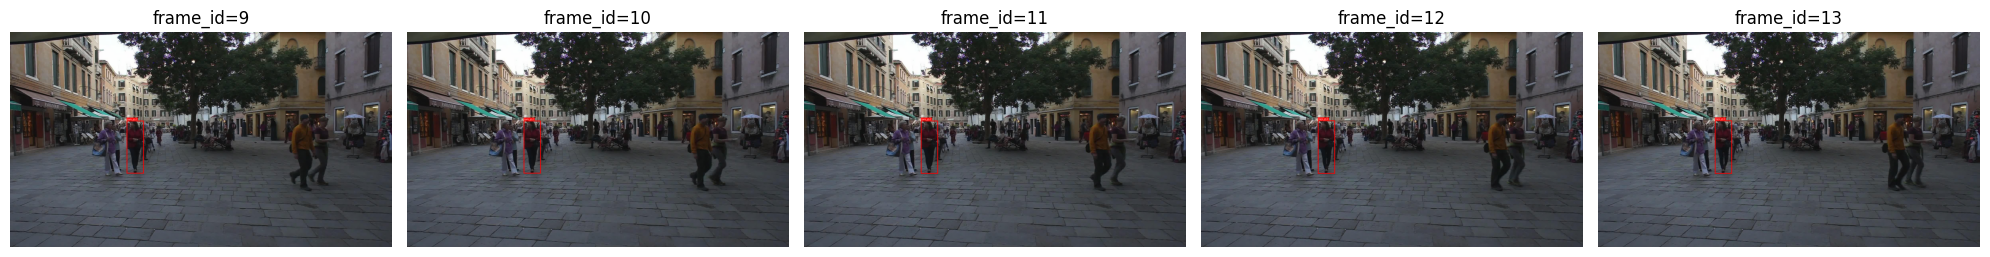

In [14]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

ann_file = Path('/media/hung/Work/Project/AI Engineer/CPV/ByteTrack/datasets/mot/annotations/train.json')
img_root = ann_file.parents[1] / 'train'

sample_idx = 5
n_frames = 5
sample = dataset.samples[sample_idx]

with open(ann_file) as f:
    data = json.load(f)

img_meta = {img['id']: img for img in data['images']}
first_fid = int(sample['fid'][0])
first_bbox = np.asarray(sample['tlwh'][0], dtype=np.float32)

# samples currently store tlwh/fid but not track_id/video_id, so recover them
# by matching the first bbox and frame_id back to the COCO annotation.
matches = []
for ann in data['annotations']:
    img = img_meta[ann['image_id']]
    if img['frame_id'] != first_fid:
        continue
    if np.allclose(np.asarray(ann['bbox'], dtype=np.float32), first_bbox, atol=1e-3):
        matches.append((ann, img))

if not matches:
    raise ValueError('Could not recover track_id/video_id for this sample. Try another sample_idx.')

ann0, img0 = matches[0]
track_id = ann0['track_id']
video_id = img0['video_id']
images_by_frame = {
    img['frame_id']: img
    for img in data['images']
    if img['video_id'] == video_id
}

norm_tlwh = []
for fid, tlwh in zip(sample['fid'][:n_frames], sample['tlwh'][:n_frames]):
    img_info = images_by_frame[int(fid)]
    img_w = img_info['width']
    img_h = img_info['height']
    scale = np.array([img_w, img_h, img_w, img_h], dtype=np.float32)
    norm_tlwh.append(np.asarray(tlwh, dtype=np.float32) / scale)

norm_tlwh = np.stack(norm_tlwh)

print(f'sample_idx={sample_idx}, video_id={video_id}, track_id={track_id}')
print('first fids:', sample['fid'][:n_frames].tolist())
print('first tlwh rows:\n', sample['tlwh'][:n_frames])
print('first tlwh rows norm:\n', norm_tlwh)

fig, axes = plt.subplots(1, n_frames, figsize=(4 * n_frames, 4))
if n_frames == 1:
    axes = [axes]

font = ImageFont.load_default()
for ax, fid, tlwh in zip(axes, sample['fid'][:n_frames], sample['tlwh'][:n_frames]):
    fid = int(fid)
    img_info = images_by_frame[fid]
    img_path = img_root / img_info['file_name']
    image = Image.open(img_path).convert('RGB')
    draw = ImageDraw.Draw(image)

    x, y, w, h = map(float, tlwh)
    x2, y2 = x + w, y + h
    draw.rectangle([x, y, x2, y2], outline='red', width=4)

    label = f'track_id={track_id}'
    text_box = draw.textbbox((0, 0), label, font=font)
    text_w = text_box[2] - text_box[0]
    text_h = text_box[3] - text_box[1]
    label_x = max(0, int(x))
    label_y = max(0, int(y) - text_h - 6)
    draw.rectangle(
        [label_x, label_y, label_x + text_w + 6, label_y + text_h + 4],
        fill='red',
    )
    draw.text((label_x + 3, label_y + 2), label, fill='white', font=font)

    ax.imshow(image)
    ax.set_title(f'frame_id={fid}')
    ax.axis('off')

plt.tight_layout()


In [19]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset=dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory="cuda",
    drop_last=True
)

In [20]:
for loader in train_loader:
    print(loader['x_seq'][0])
    break

tensor([[ 9.6589e-01,  4.5694e-01,  3.1771e-02,  1.7870e-01,  0.0000e+00,
          0.0000e+00,  1.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 9.6901e-01,  4.5787e-01,  3.2812e-02,  1.8056e-01,  3.1250e-03,
          9.2593e-04,  1.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 9.7188e-01,  4.5880e-01,  3.4375e-02,  1.8241e-01,  2.8646e-03,
          9.2593e-04,  1.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 9.7500e-01,  4.5972e-01,  3.5417e-02,  1.8426e-01,  3.1250e-03,
          9.2593e-04,  1.0000e+00,  1.0000e+00,  3.3333e-02,  0.0000e+00],
        [ 9.7812e-01,  4.6065e-01,  3.6458e-02,  1.8611e-01,  3.1250e-03,
          9.2593e-04,  1.0000e+00,  1.0000e+00,  6.6667e-02,  0.0000e+00],
        [ 9.7786e-01,  4.6343e-01,  3.5937e-02,  1.8796e-01, -2.6042e-04,
          2.7778e-03,  1.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 9.7786e-01,  4.6620e-01,  3.5937e-02,  1.8981e-01,  0.0000e+00,
          2.7778e-03,  1.0000e+0